# Chapter 4: Comparing Images and Patients

<a href="https://colab.research.google.com/github/choilab-jefferson/medimage/blob/main/Chapter04_Image_Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Chapters 1–3 measured **one** scan. Research needs to compare many: this patient against that one,
before treatment against after, one hospital's cohort against another's.

Comparison sounds easy and is full of traps. Two scans are rarely on the same grid, the patient is
never in exactly the same position twice, and — the trap that survives all the others — two people
are simply different sizes.

By the end you will be able to:

1. Explain why two images with identical array shapes can cover different amounts of the body.
2. Put images onto a common grid by **resampling**, and choose an interpolation that suits the data.
3. Move images around: shifts, rotations, and the affine transform that covers both.
4. Measure how similar two images are, and use that measure to *find* the alignment.
5. Normalize a measurement so that two patients of different sizes can be compared at all.

That last step is what turns Chapter 6's muscle area into a number with a published cut-off.

### Before you start

| | |
|---|---|
| **Builds on** | Chapters 1–3. Section 5 re-uses Chapter 2's body-finding cut at −500 HU and Chapter 3's pixel-count-to-cm² step |
| **Downloads** | Two Pancreas-CT subjects (~40 MB each), and six more in section 5 |
| **Longest wait** | Section 5 loads six subjects, so allow a few minutes on a cold cache |
| **Beyond the setup cell** | Nothing extra to install |
| **Hardware** | Any laptop. No GPU needed |

This is the last of the foundation chapters, and the one whose lesson is least about code. Sections
2 to 4 are mechanical — resample, move, score. Section 5 is the one to slow down for: it is a
decision about what your measurement *means*, and the chapter shows it being made badly on purpose.

## Setup

In [1]:
# --- Setup: Google Colab (primary) and local checkout (testing) ---------------
REPO_URL = "https://github.com/choilab-jefferson/medimage.git"
REPO_DIR = "medimage"

import os
import pathlib
import subprocess
import sys

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ModuleNotFoundError:
    IN_COLAB = False

if IN_COLAB:
    # On Colab the repository is not present yet, so clone it and install the
    # few packages that are not part of the default runtime.
    if not pathlib.Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    os.chdir(REPO_DIR)
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "pydicom", "remotezip"],
        check=True,
    )
else:
    # Locally the notebook already lives inside the repository; walk up until
    # we find the module that the notebooks import.
    root = pathlib.Path.cwd().resolve()
    while not (root / "medimage_data.py").is_file() and root != root.parent:
        root = root.parent
    os.chdir(root)

print("Running on Colab:", IN_COLAB)
print("Working directory:", pathlib.Path.cwd().name)

Running on Colab: False
Working directory: medimage


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi

import medimage_data as md

vol_a, spacing_a, _ = md.load_series(md.fetch_pancreas_ct(0))
vol_b, spacing_b, _ = md.load_series(md.fetch_pancreas_ct(1))

slice_a = vol_a[len(vol_a) // 2].astype(np.float32)
slice_b = vol_b[len(vol_b) // 2].astype(np.float32)

print(f"patient A: array {slice_a.shape}, pixel {spacing_a[1]:.3f} mm")
print(f"patient B: array {slice_b.shape}, pixel {spacing_b[1]:.3f} mm")

PANCREAS_0076: 210 slices in data/pancreas-ct/PANCREAS_0076
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


PANCREAS_0021: 223 slices in data/pancreas-ct/PANCREAS_0021
Source: Roth H, Farag A, Turkbey EB, Lu L, Liu J, Summers RM (2016). Data From Pancreas-CT. The Cancer Imaging Archive. https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU  (CC BY 3.0)


patient A: array (512, 512), pixel 0.898 mm
patient B: array (512, 512), pixel 0.957 mm


## 1. Same array, different body

Both slices are 512 × 512. It is tempting to conclude they are comparable. They are not.

Patient A's pixels are 0.898 mm across and patient B's are 0.957 mm. So the same 512 pixels cover a
different width of body — the arrays match, the anatomy does not.

Anything you count in *pixels* is therefore not comparable between them. Anything you measure in
*centimeters* is. This is the first reason Chapter 3 insisted on converting pixel counts into real
units immediately.

In [3]:
for name, sl, sp in [("A", slice_a, spacing_a), ("B", slice_b, spacing_b)]:
    width_cm = sl.shape[1] * sp[2] / 10
    print(f"patient {name}: {sl.shape[1]} px x {sp[2]:.3f} mm = {width_cm:.1f} cm across")

difference = (slice_a.shape[1] * spacing_a[2]) - (slice_b.shape[1] * spacing_b[2])
print(f"\nthe two fields of view differ by {abs(difference) / 10:.1f} cm")

patient A: 512 px x 0.898 mm = 46.0 cm across
patient B: 512 px x 0.957 mm = 49.0 cm across

the two fields of view differ by 3.0 cm


## 2. Resampling: putting images on a common grid

**Resampling** rebuilds an image on a different grid. To compare A and B pixel by pixel, first make
their pixels the same physical size.

The catch is that the new pixel centers fall *between* the old ones, so their values have to be
estimated. That estimate is **interpolation**, and the `order` argument chooses the method:

- `order=0` — nearest neighbor. Copies the closest value. Never invents new ones, so it is the
  only correct choice for **label masks**, where 1 means liver and 2 means kidney and 1.5 means
  nothing at all.
- `order=1` — linear. Blends neighbors. The sensible default for images.
- `order=3` — cubic. Smoother, slightly sharper, slower, and can overshoot past the original range.

In [4]:
zoom_factor = (spacing_b[1] / spacing_a[1], spacing_b[2] / spacing_a[2])
slice_b_resampled = ndi.zoom(slice_b, zoom_factor, order=1)

print(f"zoom factor: {zoom_factor[0]:.3f}")
print(f"patient B: {slice_b.shape} -> {slice_b_resampled.shape}")
print(f"pixel size now {spacing_b[2] / zoom_factor[1]:.3f} mm, matching patient A")

zoom factor: 1.065
patient B: (512, 512) -> (545, 545)
pixel size now 0.898 mm, matching patient A


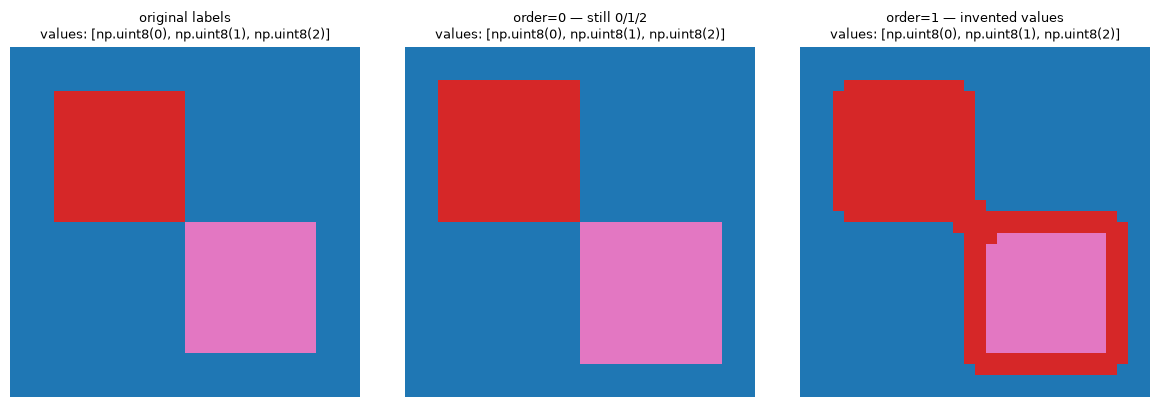

In [5]:
# Why order matters for masks: resample a label image both ways.
labels = np.zeros((8, 8), dtype=np.uint8)
labels[1:4, 1:4] = 1        # "liver"
labels[4:7, 4:7] = 2        # "kidney"

nearest = ndi.zoom(labels, 4, order=0)
linear = ndi.zoom(labels, 4, order=1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (img, title) in zip(axes, [(labels, "original labels"),
                                   (nearest, "order=0 — still 0/1/2"),
                                   (linear, "order=1 — invented values")]):
    ax.imshow(img, cmap="tab10", vmin=0, vmax=3)
    ax.set_title(f"{title}\nvalues: {sorted(np.unique(img))[:5]}", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

The linear version has produced values like 0.4 and 1.6. There is no organ number 1.6. Interpolating
labels this way silently corrupts them — always use `order=0` for masks.

## 3. Moving an image

Patients are not in identical positions from scan to scan. Correcting for that means moving one
image until it lines up with the other. Three kinds of movement cover most of it:

- **Shift** — slide it. `ndi.shift`
- **Rotation** — turn it. `ndi.rotate`
- **Affine** — the general case: shift, rotate, scale and shear in one matrix. `ndi.affine_transform`

All three need a `cval`, the value used for pixels pulled in from outside the original image. On CT
that should be **−1024**, the value of air. Leaving it at the default 0 fills the border with
something that reads as water, which then contaminates every measurement you make afterwards.

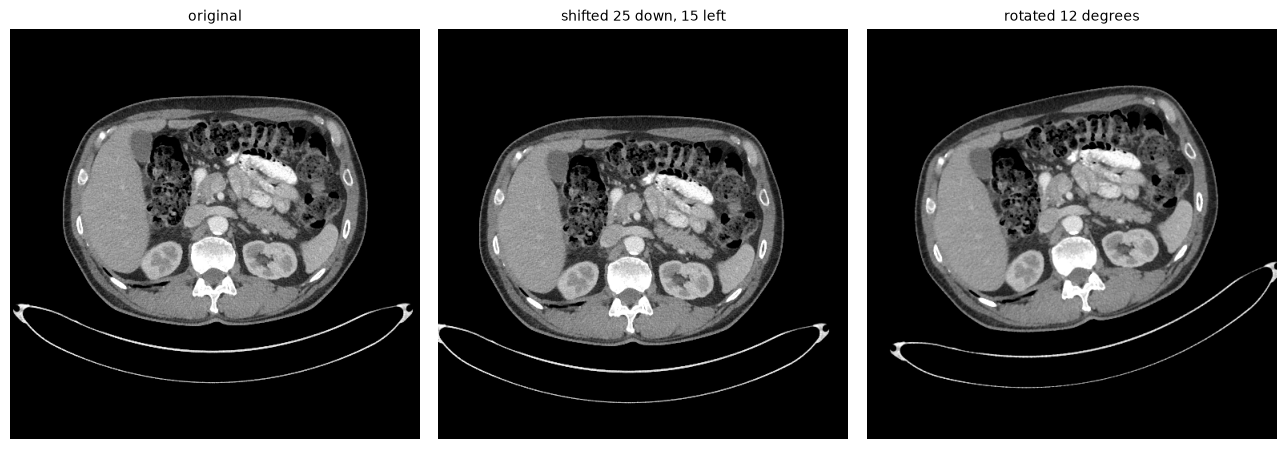

In [6]:
shifted = ndi.shift(slice_a, (25, -15), order=1, cval=-1024)
rotated = ndi.rotate(slice_a, 12, reshape=False, order=1, cval=-1024)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.4))
for ax, (img, title) in zip(axes, [(slice_a, "original"),
                                   (shifted, "shifted 25 down, 15 left"),
                                   (rotated, "rotated 12 degrees")]):
    ax.imshow(img, cmap="gray", vmin=-160, vmax=240)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

## 4. Measuring similarity

To align two images automatically you need a number that says how well they match. The simplest is
**mean absolute error**: the average difference, pixel by pixel.

$$\text{MAE} = \text{average of } |A - B|$$

Identical images score 0. The more they disagree, the higher it climbs.

In [7]:
def mae(a, b):
    """Mean absolute difference between two images of the same shape."""
    return float(np.abs(a - b).mean())


print(f"a slice against itself      {mae(slice_a, slice_a):8.1f} HU")
print(f"against a shifted copy      {mae(slice_a, shifted):8.1f} HU")
print(f"against a rotated copy      {mae(slice_a, rotated):8.1f} HU")

a slice against itself           0.0 HU
against a shifted copy         161.2 HU
against a rotated copy         110.5 HU


### Using the measure to find the alignment

Here is the whole idea behind image **registration**, stripped to its simplest form: if MAE tells
you how badly two images match, then try many alignments and keep the one with the lowest MAE.

Real registration software searches smarter and handles rotation, scaling and non-rigid warping.
But the principle is exactly this.

In [8]:
target = ndi.shift(slice_a, (12, -8), order=1, cval=-1024)   # unknown shift to recover

best = None
for dy in range(-20, 21, 4):
    for dx in range(-20, 21, 4):
        candidate = ndi.shift(target, (dy, dx), order=1, cval=-1024)
        score = mae(slice_a, candidate)
        if best is None or score < best[0]:
            best = (score, dy, dx)

score, dy, dx = best
print(f"true shift applied : (12, -8)")
print(f"shift recovered    : ({-dy}, {-dx})")
print(f"MAE before {mae(slice_a, target):.1f} HU  ->  after {score:.1f} HU")

true shift applied : (12, -8)
shift recovered    : (12, -8)
MAE before 117.4 HU  ->  after 0.7 HU


### Comparing shapes rather than intensities

When you are comparing *regions* rather than pictures, MAE is the wrong tool — use the overlap
measures. **Dice** appeared in Chapter 3; its close relative is **intersection over union (IoU)**,
sometimes called the Jaccard index:

$$\text{IoU} = \frac{\text{pixels in both}}{\text{pixels in either}}$$

Both answer the same question and always agree on which of two results is better; IoU simply
punishes disagreement a little harder.

In [9]:
def dice(a, b):
    return 2 * np.count_nonzero(a & b) / (np.count_nonzero(a) + np.count_nonzero(b))


def iou(a, b):
    return np.count_nonzero(a & b) / np.count_nonzero(a | b)


body_a = ndi.binary_fill_holes(slice_a > -500)
body_shifted = ndi.binary_fill_holes(shifted > -500)

print(f"body outline vs itself     Dice {dice(body_a, body_a):.3f}   IoU {iou(body_a, body_a):.3f}")
print(f"body outline vs shifted    Dice {dice(body_a, body_shifted):.3f}   IoU {iou(body_a, body_shifted):.3f}")

body outline vs itself     Dice 1.000   IoU 1.000
body outline vs shifted    Dice 0.801   IoU 0.668


## 5. Normalization: the trap that survives everything else

Suppose you have now done everything right — same grid, aligned, measured in square centimeters.
Patient A has 140 cm² of muscle and patient B has 115 cm². Is patient B losing muscle?

You cannot tell. A tall, broad person has more muscle than a small one **while being perfectly
healthy**. Comparing raw areas mostly measures who is bigger.

The fix is to divide by a measure of body size. In body composition the standard is to divide the
muscle area at the L3 vertebra by the square of the patient's height in meters, giving the
**skeletal muscle index**:

$$\text{SMI} = \frac{\text{muscle area at L3 (cm}^2)}{\text{height (m)}^2}$$

The published cut-offs for low muscle mass — around 41 cm²/m² for women and 43 for men — are
defined on SMI, never on raw area. Chapter 6 computes exactly this.

Height is not in these scans, so below we use the width of the body as a stand-in to show the
*effect* of normalizing. It is a demonstration of the principle, not a clinical measurement.

In [10]:
def body_width_cm(slice_hu, spacing):
    """Widest left-to-right extent of the body, in centimeters."""
    body = ndi.binary_fill_holes(slice_hu > -500)
    columns = np.where(body.any(axis=0))[0]
    return (columns[-1] - columns[0]) * spacing[2] / 10


def muscle_area_cm2(slice_hu, spacing):
    body = ndi.binary_fill_holes(slice_hu > -500)
    smooth = ndi.gaussian_filter(slice_hu, 2)
    mask = body & (smooth >= -29) & (smooth < 150)
    mask = ndi.binary_opening(mask, np.ones((3, 3)))
    return mask.sum() * spacing[1] * spacing[2] / 100


areas, widths = [], []
for i in range(6):
    v, sp, _ = md.load_series(md.fetch_pancreas_ct(i, quiet=True))
    s = v[len(v) // 2].astype(np.float32)
    areas.append(muscle_area_cm2(s, sp))
    widths.append(body_width_cm(s, sp))

areas, widths = np.array(areas), np.array(widths)
index = areas / (widths / 100) ** 2

print(f"{'subject':>8} {'area cm2':>10} {'width cm':>10} {'index':>10}")
for i in range(len(areas)):
    print(f"{i:>8} {areas[i]:>10.1f} {widths[i]:>10.1f} {index[i]:>10.0f}")

 subject   area cm2   width cm      index
       0      435.8       44.9       2160
       1      547.7       44.7       2742
       2      392.7       40.8       2357
       3      325.5       45.0       1607
       4      460.8       43.2       2473
       5      296.2       32.3       2832


### Did it work? Check, do not assume

The point of normalizing is to remove the influence of body size. So test whether it did, by asking
how strongly each measurement still tracks how big the person is.

In [11]:
print(f"raw area   vs body size : {np.corrcoef(areas, widths)[0, 1]:+.2f}")
print(f"normalized vs body size : {np.corrcoef(index, widths)[0, 1]:+.2f}")

raw area   vs body size : +0.60
normalized vs body size : -0.57


Read those two numbers carefully, because they say something more useful than "normalizing works".

The raw area correlates **+0.61** with body size: bigger people do have more muscle, so part of
what the raw number measured was simply size. That is the problem, confirmed.

After dividing by width squared the correlation is **−0.57**. It has not been removed — it has been
flipped. The correction went too far, and now the measurement makes big people look worse than they
are.

The reason is that body *width* is a poor stand-in for body *height*. Width partly reflects fatness,
not frame size, so dividing by it over-corrects. Real clinical practice divides by height squared,
and those cut-offs were validated against patient outcomes in large cohorts rather than assumed to
work.

The lesson generalizes well beyond this: **normalizing is a decision, not a formality.** Choosing a
denominator changes what your measurement means, and the only way to know whether the choice was
right is to check it — exactly as we just did.

(With six subjects these correlations are unstable anyway. Treat them as a demonstration of the
check, not as evidence about body composition.)

This is the last piece of groundwork. Chapter 6 now has everything it needs: load a scan correctly
(Chapter 1), select tissue reliably (Chapter 2), turn the selection into square centimeters and
check it (Chapter 3), and normalize it so patients can be compared (this chapter).

## Recap

| | |
|---|---|
| **Shape is not size** | Two `512 × 512` slices can cover very different amounts of body. Only `shape × spacing` is a physical size |
| **Resampling** | `ndi.zoom` onto a common grid. The zoom factor comes from the *spacings*, not from the shapes |
| **Interpolation order** | `order=1` for images. **`order=0` for masks**, always — anything else invents label values that mean nothing |
| **Moving images** | `ndi.shift` and `ndi.rotate`, with `cval=-1024` so the space that scrolls in is air rather than water |
| **Similarity** | MAE: 0 for identical, larger as they diverge. Dice compares shapes instead of intensities |
| **Finding an alignment** | Score every candidate shift and keep the best. That search *is* registration, in miniature — Chapter 10 does it properly |
| **Normalization** | Dividing by a body-size measure so two patients can be compared |

The two things most worth carrying forward:

- **`order=0` for masks.** Interpolating a label image blends label 1 and label 3 into label 2,
  which is a different organ. It fails silently and it is a common bug.
- **Normalizing is a decision, not a formality.** Dividing muscle area by body *width* squared did
  not remove the size correlation — it flipped its sign, from +0.61 to −0.57, and made big patients
  look worse than they are. The check is what revealed it. Clinical practice divides by height
  squared, using cut-offs validated against outcomes rather than assumed to work.

**Next:** Chapter 5 covers the step that has to happen before any of this touches real clinical
data — removing identifying information from DICOM files, and verifying it is gone. After that,
Chapter 6 is the destination these four chapters were building toward.

## Exercises

1. Resample patient A's slice to 2 mm pixels and back to the original size. Compare with the
   original using MAE. What has been lost, and why can it not be recovered?

   *Hint:* two `ndi.zoom` calls with reciprocal factors. The MAE will not be zero. Think about how
   many original pixels were averaged into each coarse one — that information is gone, and zooming
   back up can only interpolate, not restore.

2. Repeat the shift search with a step of 1 instead of 4. Is the answer better? How much longer does
   it take, and what does that suggest about how real registration software must work?

   *Hint:* time both with `%%time`. The cost grows with the square of the step reduction in 2D, and
   with the cube in 3D. Real software avoids this with a coarse-to-fine pyramid — search roughly on
   a shrunken image, then refine. Chapter 10 shows that pyramid mattering in practice.

3. Rotate a slice by 5 degrees using `order=0` and `order=3` and compare with MAE. Which
   interpolation preserves the intensities better, and would your answer change for a label mask?

   *Hint:* `order=3` wins on the image and is wrong on the mask. Check the second half by running
   `np.unique` on a rotated label image — `order=3` will have produced values that were never a
   label, and can overshoot outside the original range entirely.

4. Compute muscle area for five subjects with and without normalization. Which ranks the subjects
   differently, and which ranking would you trust?

   *Hint:* section 5 already builds the per-subject loop; reuse it and sort by each column. Neither
   ranking deserves much trust here — with this few subjects, and body width standing in for height,
   the point of the exercise is that the two disagree at all.

## References

- [scipy.ndimage documentation](https://docs.scipy.org/doc/scipy/reference/ndimage.html)
- Prado CM, Lieffers JR, McCargar LJ, et al. *Prevalence and clinical implications of sarcopenic
  obesity in patients with solid tumors of the respiratory and gastrointestinal tracts.*
  Lancet Oncology. 2008;9(7):629–635. — the source of the widely used SMI cut-offs.
- Roth H, et al. (2016). *Data From Pancreas-CT.* The Cancer Imaging Archive.
  [doi:10.7937/K9/TCIA.2016.tNB1kqBU](https://doi.org/10.7937/K9/TCIA.2016.tNB1kqBU)